# Tool 호출 루프가 있는 LangGraph Chatbot

일반 Chat Model은 질문을 읽고 답변을 한 번 생성한다. Tool이 연결된 Chat Model은 답변에 외부 정보가 필요하면 검색이나 계산 같은 기능의 **실행 요청**을 만들 수 있다.

모델이 Tool을 직접 실행하는 것은 아니다. <br>
모델은 `AIMessage.tool_calls`를 만들고, LangGraph의 Tool Node가 요청을 실행해 `ToolMessage`로 돌려준다. <br>
모델은 그 결과를 다시 읽고 최종 답변을 만들거나 다른 Tool을 요청한다.


## 패키지 설치

Tool loop에 필요한 LangGraph, OpenAI와 Tavily 통합을 설치한다. 이 셀은 외부 검색이나 유료 모델을 호출하지 않는다.


In [1]:
%pip install -U langgraph langchain-openai langchain-tavily python-dotenv


Note: you may need to restart the kernel to use updated packages.


## OpenAI와 Tavily 인증 준비

`.env` 또는 운영체제 환경 변수에서 필수 키를 불러온다. 값 자체는 출력하지 않고, LangSmith가 없을 때도 그래프의 핵심 경로는 유지한다.


In [2]:
import os
from dotenv import find_dotenv, load_dotenv

dotenv_path = find_dotenv(usecwd=True)
load_dotenv(dotenv_path, override=False)

if os.getenv("LANGSMITH_API_KEY"):
    os.environ.setdefault("LANGSMITH_TRACING", "true")
    os.environ.setdefault("LANGSMITH_PROJECT", "langgraph-tool-chat")

OPENAI_CHAT_MODEL = os.getenv("OPENAI_CHAT_MODEL", "gpt-5.6-luna")


## Tavily Tool의 입력과 반환 구조

Tavily(태빌리)는 AI 애플리케이션이 최신 웹 문서를 검색하도록 제공하는 검색 서비스이다.<br>
`TavilySearch`는 이 서비스를 LangChain Tool 형식으로 감싼 객체이다.

- `Tool`: 모델에 보여 줄 이름·설명·입력 규칙과 실제 Python 실행 기능을 함께 가진 객체이다.
- `args_schema`: Tool이 받을 수 있는 인자 이름과 자료형을 정의한 입력 스키마이다. `TavilySearch`에서는 `query` 등의 값을 검사하고, `bind_tools()`가 모델에 전달할 함수 설명의 근거가 된다.
- `invoke()` 입력: `query`가 담긴 딕셔너리이다.
- `invoke()` 출력: 검색어와 `results` 목록 등이 담긴 딕셔너리이다.

Agent에 연결하기 전에 직접 호출하면 Tavily 인증·입력 문제를 뒤의 모델 판단이나 그래프 연결 문제와 분리할 수 있다.


In [3]:
from langchain_tavily import TavilySearch

# 웹 검색 도구 (관련 내용 최대 2건 검색)
tavily_tool = TavilySearch(max_result=2)

# tavily 정상 동작 확인
tavily_tool.invoke({"query": "LangGraph에서 Node란 무엇인가?"})

{'error': ValueError('Error 401: The account associated with this API key has been deactivated. If you wish to reactivate your subscription, please contact our team at support@tavily.com.')}

## Tool 스키마를 Chat Model에 연결하기

### 호출 전에 넣는 `tools`

- `tools`: 모델이 선택할 수 있도록 전달하는 Tool 객체 목록이다.
- `bind_tools(tools)`: 각 Tool의 이름·설명·`args_schema`를 모델 요청에 포함한 새 Runnable을 만든다.

### 호출 뒤에 나오는 `tool_calls`

- `tool_calls`: 모델이 `tools`를 보고 만든 실행 요청 목록이다.
    - 이름이 비슷하지만 Tool 객체 목록이 아니라 **모델의 출력**이며, 이 단계에서는 Python Tool이 아직 실행되지 않았다.
    - 실제 실행은 뒤의 Tool Node가 맡는다.


In [5]:
from langchain_openai import ChatOpenAI

# 1. llm 모델 객체 생성
llm = ChatOpenAI(
    model=OPENAI_CHAT_MODEL,
    use_responses_api=True
)

# 2. llm에게 전달할 tool 목록 생성
tools = [tavily_tool]

# 3. llm과 tool 목록이 연결된 새 Runnable 생성
llm_with_tools = llm.bind_tools(tools)

print("llm:", type(llm).__name__)
print("llm_with_tools:", type(llm_with_tools).__name__)

llm: ChatOpenAI
llm_with_tools: _ChatModelBinding


## Tool 호출 루프를 완성할 네 구성 요소

여기까지 만든 `llm_with_tools`는 Tool의 이름·설명·입력 스키마를 알고 **실행 요청을 작성할 수 있는 모델**이다. `bind_tools()`는 Tool을 모델에 알려 줄 뿐 Tavily를 실행하지 않는다.

모델의 요청을 실제 실행하고 그 결과를 다시 모델에게 전달하려면 다음 네 구성 요소가 필요하다.

1. `State`: 질문·Tool 요청·Tool 결과·최종 답변을 이어 주는 공유 메시지 규칙이다.
2. `chatbot`: State를 읽어 일반 답변 또는 `tool_calls`가 담긴 `AIMessage`를 만드는 Node이다.
3. `ToolNode`: `tool_calls`를 읽어 실제 Tool을 실행하고 `ToolMessage`를 만드는 Node이다.
4. `tools_condition`: 최신 `AIMessage`에 Tool 요청이 있는지 보고 다음 경로를 정하는 route function이다.

```text
HumanMessage → chatbot → AIMessage → tools_condition
                         ├─ tool_calls 있음 → ToolNode → ToolMessage → chatbot
                         └─ tool_calls 없음 → END
```

다음 네 셀에서는 이 부품을 **정의만** 하므로 화면 출력이나 외부 호출이 발생하지 않는다. 뒤의 `네 구성 요소를 Tool 호출 루프로 조립하기`에서 `StateGraph`에 등록하고 `compile()`한 뒤, `graph.invoke()`를 호출할 때 하나의 반복 구조로 동작한다.

### 1. 대화 이력을 합칠 State 규칙 정의하기

`State`는 Node 사이에서 공유하는 데이터 구조이다. 이 셀에서는 메시지를 직접 저장하지 않고, 그래프 실행 중 새 message를 기존 목록에 합치는 규칙을 선언한다.

- 저장 대상: `HumanMessage`(질문), `AIMessage`(답변 또는 Tool 요청), `ToolMessage`(Tool 결과)이다.
- 실행 시 입력: 기존 `messages`와 Node가 반환한 새 message이다.
- 변환: `add_messages` reducer가 두 값을 실행 순서대로 합친다.
- 출력: 다음 Node가 읽을 수 있는 갱신된 `messages`이다.
- 다음 사용처: Tool 결과가 추가된 뒤 `chatbot`이 이전 질문과 요청까지 함께 읽는다.


In [6]:
from typing import Annotated, TypedDict

from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

### 2. 모델의 다음 행동을 정하는 chatbot Node 만들기

`chatbot`은 현재 State의 전체 `messages`를 `llm_with_tools`에 전달하는 Node이다. 모델은 일반 답변 또는 `tool_calls`가 담긴 `AIMessage`를 만들지만, 이 Node가 Tool을 직접 실행하지는 않는다.

- 입력: `HumanMessage`·`AIMessage`·`ToolMessage`가 누적된 현재 State이다.
- 변환: 모델이 지금 답할지 Tool 실행을 요청할지 결정한다.
- 출력: 새 `AIMessage` 하나이다.
- 다음 사용처: `add_messages`가 State에 합치고 `tools_condition`이 다음 경로를 판단한다.

첫 호출에서는 Tool 요청을 만들 수 있고, Tool 결과가 State에 추가된 뒤 다시 호출되면 그 결과를 근거로 최종 답변을 만들 수 있다. 이 셀은 함수 정의 단계이므로 모델 API는 아직 호출하지 않는다.


In [13]:
def chatbot(state:State) -> dict:
    # State의 메시지를 tool이 묶여있는 LLM에 전달
    # -> tool 사용 조건은 아래에서 정의할 예정
    response = llm_with_tools.invoke(state["messages"])
    return {"messages": [response]}

### 3. Tool 요청을 실제 실행하는 Tool Node 만들기

`chatbot`이 만든 `tool_calls`는 **실행 요청**일 뿐 실제 검색 결과가 아니다. `ToolNode`는 요청의 Tool 이름과 인자를 읽고 허용된 Python Tool을 실행한 뒤, 결과를 `ToolMessage`로 바꾸는 Node이다.

```text
tool_calls의 name·args·id
        ↓ 이름으로 Tool 선택
tool.invoke(args)
        ↓ 결과와 같은 호출 ID 연결
ToolMessage(content, tool_call_id=id)
```

- 입력: 최신 `AIMessage.tool_calls`의 `name`·`args`·`id`이다.
- 변환: `name`으로 허용된 Tool을 찾고 `tool.invoke(args)`로 실행한다.
- 출력: 실행 결과와 같은 호출 ID를 담은 `ToolMessage` 목록이다.
- 다음 사용처: `add_messages`가 결과를 State에 합치고 `tools → chatbot` Edge가 모델로 돌려보낸다.

이 Node는 Tool 요청의 유무를 판단하지 않는다. 뒤의 `tools_condition`이 `tool_calls`가 있을 때만 이 Node로 보낸다. 내부 원리를 확인하기 위해 직접 구현하며, 노트북 마지막에는 같은 역할의 LangGraph 기본 제공 `ToolNode`로 교체한다.


In [14]:
import json

from langchain_core.messages import ToolMessage

class ToolNode:
    """AIMessage.tool_calls를
    허용된 python tool(함수) 결과로 바꾸는 Node이다.
    """

    # 1. 전달 받은 tool 목록
    #   {tool 이름 : 실제 tool 함수} 형태의 dict로 변환
    def __init__(self, tools):
        self.tools_by_name = {
            tool.name: tool for tool in tools
        }

    # 2. __call__(): 객체를 함수처럼 호출할 수 있게하는 메서드
    # ex) tool_node = ToolNode(tools)
    #     tool_node.__call__() == tool_node()
    def __call__(self, state:State):
        # 요청 읽기: state에 messages가 없으면 []
        #           있으면 마지막 message를 tool 요청으로 사용
        messages = state.get("messages", [])

        if not messages:
            raise ValueError("State에 messages가 없습니다.")

        # state의 마지막 메시지
        request_message = messages[-1]

        # 3. Tool 실행: 각 tool_calls의 name, args, id를 차례대로 처리
        outputs = [] # tool 요청 결과를 저장할 list

        for tool_call in request_message.tool_calls:
            tool_name = tool_call["name"]

            if tool_name not in self.tools_by_name:
                raise ValueError(f"허용되지 않은 Tool 요청입니다: {tool_name}")

            # args: args schema 검사를 거쳐 Tool에 입력할 값 (dict)
            tool_result = self.tools_by_name[tool_name].invoke(
                tool_call["args"]
            )

            # 4. tool 결과를 ToolMessage로 변환하여 outputs 누적
            outputs.append(
                ToolMessage(
                    # 결과를 만든 Tool 이름
                    name = tool_name,

                    # Tool 결과(dict)를 JSON으로 변환
                    content = json.dumps(
                        tool_result,
                        ensure_ascii=False,
                    ),

                    # tool 요청 id
                    tool_call_id = tool_call["id"]
                )
            )

        # 5. State 갱신 값을 반환
        # -> ToolNode 종료 후 add_messages가 State['messages'] 제일 뒤에 outputs 추가(갱신 작업)
        return {"messages": outputs}

# 6. ToolNode 노드 생성
tool_node = ToolNode(tools)

### 4. Tool 실행 여부를 판단하는 route function 만들기

`tools_condition`은 Conditional Edge 자체가 아니라, 현재 State를 읽고 **다음 목적지 label만 반환하는 함수**이다.

- 입력: `chatbot`이 방금 추가한 최신 `AIMessage`이다.
- 변환: `tool_calls` 목록이 비어 있는지 확인한다.
- 출력: 요청이 있으면 `"tools"`, 없으면 `END`를 반환한다.
- 다음 사용처: `add_conditional_edges()`가 반환값을 실제 목적지와 연결한다.

이 함수는 Tool을 실행하거나 State를 수정하지 않는다. 실제 Conditional Edge는 뒤에서 `add_conditional_edges()`가 반환값과 목적지를 연결할 때 만들어진다. 이 셀도 함수 정의 단계이므로 화면 출력은 없다.


In [15]:
from langgraph.graph import END

# 마지막 AIMessage의 tool_calls 유무로 다음 경로를 결정하는 route Function 정의
def tools_condition(state:State):

    # 1. 분기를 판단할 message channel 읽기
    messages = state.get("messages",[])
    if not messages:
        raise ValueError("조건을 판정할 messages가 존재하지 않음.")

    # 2. chatbot Node에서 추가한 마지막 메시지(AIMessage) 꺼내기
    last_message = messages[-1]

    # 3. 마지막 메시지가 'tool_calls' 인지 확인
    has_tool_calls = bool(
        # last_message에서 "tool_calls"얻어오기, 없으면 []
        getattr(last_message, "tool_calls", [])
    )
    print(f'has_tool_calls: {has_tool_calls}')

    # 4. has_tool_calls가 True이면 Node Label("tools")
    # False이면 END 반환
    return "tools" if has_tool_calls else END

## 네 구성 요소를 Tool 호출 루프로 조립하기

앞의 네 셀은 부품의 역할만 정의했다. 이제 `StateGraph(State)`에 두 Node를 등록하고, route function의 반환값을 실제 목적지에 연결한다.

- `State` → `StateGraph(State)`: 모든 Node가 공유할 message 규칙이다.
- `chatbot` → `add_node("chatbot", chatbot)`: 다음 `AIMessage`를 만드는 Node이다.
- `tool_node` → `add_node("tools", tool_node)`: Tool 요청을 실행하는 Node이다.
- `tools_condition` → `add_conditional_edges(...)`: `tools` 또는 `END` 경로를 선택한다.
- Tool 결과 재입력 → `add_edge("tools", "chatbot")`: `ToolMessage`를 모델이 다시 읽게 한다.

### `add_conditional_edges()`의 세 인자 읽기

`add_conditional_edges()`는 **특정 Node가 끝난 뒤 route function을 실행하고, 반환값에 맞는 다음 목적지로 이동하라**는 규칙을 등록한다. 이 코드를 작성하는 시점에는 분기나 Tool 실행이 일어나지 않고, 뒤에서 `graph.invoke()`가 실행될 때 사용된다.

- 첫 번째 인자 `"chatbot"`: 어느 Node가 끝난 뒤 분기할지 지정한다.
- 두 번째 인자 `tools_condition`: 현재 State를 받아 `"tools"` 또는 `END`를 반환한다.
- 세 번째 인자 `path_map`: route function의 **반환값을 실제 목적지로 바꾸는 딕셔너리**이다.
  - 왼쪽 값: `tools_condition`이 반환한 값이다.
  - 오른쪽 값: LangGraph가 실제로 이동할 Node 이름 또는 종료 지점이다.

```text
chatbot 실행 완료
    ↓
tools_condition(state)
    ├─ "tools" 반환 → path_map["tools"] → "tools" Node 실행
    └─ END 반환     → path_map[END]     → 그래프 종료
```

따라서 `{"tools": "tools", END: END}`는 `"tools"`가 나오면 이름이 `"tools"`인 Node로 이동하고, `END`가 나오면 실행을 끝내라는 분기표이다. 현재는 반환값과 목적지 이름이 같지만, 둘의 역할을 구분해 보여 주기 위해 명시적으로 작성한다.

`StateGraph`는 State 스키마를 기준으로 Node와 Edge를 등록하는 builder이다. 등록만으로 실행되지는 않으며 `compile()`해야 호출 가능한 그래프가 된다.

![LangGraph 공식 Agent Workflow](https://cdn.jsdelivr.net/gh/goat-skn-ai/image-repo@7f008bd902003af9b0138e956af0be37ffa7a9ff/08_llm/08_langgraph/01_langgraph_basics/langgraph_official_agent_loop.png)

1. `In`: 뒤의 실행 셀에서 `initial_state`에 담은 사용자 질문이 들어온다.
2. `LLM call`: `chatbot` Node가 답변 또는 `AIMessage.tool_calls`를 만든다.
3. `action`: Tool 요청이 생기면 `tools_condition`이 `tools` 경로를 고른다. 요청이 없으면 `END`를 고른다.
4. `Tool`: `tool_node`가 요청을 실행하고 `ToolMessage`를 만든다.
5. `feedback`: `add_messages`가 결과를 State에 합치고 `tools → chatbot` Edge가 모델의 다음 판단으로 돌려보낸다.
6. `Out`: 마지막 `AIMessage.tool_calls`가 비면 `END`에서 최종 State를 반환한다.

그림의 feedback 화살표가 코드의 반복 Edge이다. 모델이 Tool을 더 요청하면 `chatbot → tools → chatbot`이 반복된다. 공식 그림의 `Tool → Out`은 일반화된 표현이다. 이 실습에는 `tools → END` Edge가 없으므로 Tool 결과는 항상 `chatbot`으로 돌아가며, 재호출된 `chatbot`이 Tool 요청 없는 최종 `AIMessage`를 만들 때 Conditional Edge가 `END`를 선택한다.

> 이미지 출처: [LangChain 공식 문서 - Workflows and agents](https://docs.langchain.com/oss/python/langgraph/workflows-agents)


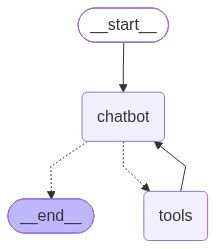

In [16]:
from langgraph.graph import END, START, StateGraph

# 1. Builder 생성
workflow = StateGraph(State)

# 2. Node 등록
workflow.add_node("chatbot", chatbot)
workflow.add_node("tools", tool_node)

# 3. Edge 연결
workflow.add_edge(START, "chatbot")
workflow.add_edge("tools", "chatbot")

# 4. add_conditional_edges(source, path, path_map)
# - chatbot 실행 뒤 분기 규칙을 등록
workflow.add_conditional_edges(
    "chatbot",          # 어떤 노드가 끝난 뒤 분기할 것인가?
    tools_condition,    # 다음 목적지를 판단할 함수
    {
        "tools": "tools", # tools_condition 반환 값에 따라서
        END: END,         # 연결될 실제 노드 매핑
    }
)

# 5. compile() : 실행 가능한 상태로 변경
graph = workflow.compile()
display(graph)

## 검색이 필요한 질문의 message 흐름 확인

`invoke(initial_state)`는 LLM을 한 번만 호출하는 메서드가 아니다. `START`부터 `END`까지 이동하며 조건에 따라 chatbot과 tools Node를 여러 번 실행한 뒤 최종 State를 반환한다.

검색이 한 번 실행되면 `messages`는 보통 다음 순서가 된다. 모델이 추가 검색을 요청하면 가운데 두 단계가 반복될 수 있다.

```text
HumanMessage
→ AIMessage(tool_calls: name·args·id)
→ ToolMessage(tool_call_id: 같은 id)
→ 최종 AIMessage(tool_calls: [])
```

전체 State에는 검색 본문과 응답 block도 들어 있다. 아래 코드는 경로를 쉽게 읽도록 message 종류, Tool 이름과 호출 ID만 `list[dict]`로 요약한다.


In [17]:
from langchain_core.messages import HumanMessage

def summarize_messages(messages: list[AnyMessage]) -> list[dict]:
    """message 본문을 제외하고 종류와 Tool 호출 연결 정보만 반환"""

    return [
        {
            "message_type": message.type,  # human·ai·tool 중 message 종류
            "tool_calls": [  # AIMessage가 요청한 Tool 이름과 호출 ID 목록
                {"name": tool_call["name"], "id": tool_call["id"]}
                for tool_call in getattr(message, "tool_calls", [])
            ],
            # ToolMessage가 아니면 연결할 호출 ID가 없으므로 None을 사용한다.
            "tool_call_id": getattr(message, "tool_call_id", None),
        }
        for message in messages
    ]

# 1. 입력 준비
user_input = "LangGraph의 Node와 Edge를 설명하고, 필요하면 검색 Tool을 사용해줘"

initial_state = {
    "messages": [HumanMessage(content=user_input)],
}

# 2. 실행 후 결과 반환 받기
final_state = graph.invoke(initial_state) # START -> END

# 3. 결과 출력
trace_summary = summarize_messages(final_state["messages"])
display(trace_summary)

has_tool_calls: True
has_tool_calls: False


[{'message_type': 'human', 'tool_calls': [], 'tool_call_id': None},
 {'message_type': 'ai',
  'tool_calls': [{'name': 'tavily_search',
    'id': 'call_qx9Zw8VudvlE97nTWJ1jthS3'}],
  'tool_call_id': None},
 {'message_type': 'tool',
  'tool_calls': [],
  'tool_call_id': 'call_qx9Zw8VudvlE97nTWJ1jthS3'},
 {'message_type': 'ai', 'tool_calls': [], 'tool_call_id': None}]

## 최종 AIMessage의 content 구조 확인

마지막 `AIMessage`는 Tool 결과를 읽고 만든 최종 응답이다. Responses API에서는 응답을 다룰 때 다음 세 값을 구분해야 한다.

- `content`: 공급자가 반환한 원본 content이다. 문자열일 수도 있고 block 목록일 수도 있다.
- `content_blocks`: 공급자별 content를 공통 block 목록으로 정규화한 값이다. block의 종류와 구조를 확인할 때 사용한다.
- `text`: text block만 모은 문자열이다. 화면 렌더링이나 일반 문자열 처리를 할 때 사용한다.

아래 코드는 `content_blocks`에서 사용자에게 공개할 `type='text'` block의 `type`과 `text`만 선택한다.


In [19]:
final_message = final_state["messages"][-1]

public_content_block = [
    {
        "type": block["type"],
        "text": block.get("text", "")
    }
    for block in final_message.content_blocks if block.get("type") == "text"
]

print(public_content_block)

[{'type': 'text', 'text': '# LangGraph의 Node와 Edge\n\nLangGraph는 LLM 애플리케이션이나 에이전트의 실행 흐름을 **그래프**로 표현하는 프레임워크입니다.\n\n- **Node**: 실제 작업을 수행하는 함수\n- **Edge**: Node와 Node 사이의 실행 흐름\n- **State**: Node들이 공유하는 데이터\n- **Graph**: Node, Edge, State를 조합한 실행 구조\n\n공식 문서에서도 일반적인 Node의 형태를 `State -> Partial[State]`로 설명합니다. 즉, Node는 현재 상태를 읽고 상태의 일부를 업데이트합니다.  \n[LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api)\n\n---\n\n## 1. Node란?\n\nNode는 그래프 안에서 실행되는 하나의 작업 단위입니다.\n\n예를 들면 다음과 같은 작업을 Node로 만들 수 있습니다.\n\n- 사용자 질문 분류\n- LLM 호출\n- 검색 수행\n- 도구 실행\n- 결과 검증\n- 답변 생성\n- 오류 처리\n\nNode는 보통 다음과 같은 Python 함수입니다.\n\n```python\ndef node_function(state):\n    # state를 읽고 작업 수행\n    return {\n        "some_key": "updated value"\n    }\n```\n\nNode 함수는 현재 `state`를 입력으로 받고, 변경할 상태의 일부를 반환합니다.\n\n### 예시\n\n```python\nfrom typing import TypedDict\n\nclass MyState(TypedDict):\n    question: str\n    answer: str\n\ndef answer_node(state: MyState):\n    question = state["question"]\n\

## Tool이 필요 없는 질문의 짧은 경로

같은 그래프라도 모델이 `tool_calls`를 만들지 않으면 Tool Node를 거치지 않는다. 일반적인 의견 질문을 넣어 `START → chatbot → END`의 짧은 경로와 앞의 반복 경로를 비교한다.

모델의 Tool 선택은 확률적일 수 있으므로 질문 문장만 보고 경로를 단정하지 않고, 마지막 `AIMessage.tool_calls`와 분기 로그를 확인한다.


In [22]:
user_input = "AI가 인간의 삶을 어떻게 변화 시킬지 마크다운 형식으로 정리해줘"

initial_state = {
    "messages": [HumanMessage(content=user_input)],
}

final_state = graph.invoke(initial_state)

trace_summary = summarize_messages(final_state["messages"])
print(trace_summary)

has_tool_calls: False
[{'message_type': 'human', 'tool_calls': [], 'tool_call_id': None}, {'message_type': 'ai', 'tool_calls': [], 'tool_call_id': None}]


## 최종 텍스트를 Markdown으로 렌더링하기

`Markdown()`은 문자열을 받아 제목·목록 같은 Markdown 문법을 화면에 렌더링한다. 원본 `AIMessage.content`는 block 목록일 수 있으므로 문자열 인자가 필요한 곳에 그대로 전달하지 않는다.

앞에서 구분한 `AIMessage.text`를 사용하면 State와 원본 content 구조는 유지하면서 사용자에게 보여 줄 텍스트만 문자열로 꺼낼 수 있다.


In [23]:
from IPython.display import Markdown

answer_text = final_state["messages"][-1].text
Markdown(answer_text)

# AI가 인간의 삶을 변화시키는 방식

인공지능(AI)은 단순히 새로운 기술을 넘어 **일하는 방식, 배우는 방법, 건강 관리, 인간관계와 사회 구조** 전반을 바꿀 것으로 예상됩니다.

## 1. 일과 직업의 변화

### 긍정적 변화

- 반복적이고 단순한 업무 자동화
- 문서 작성, 번역, 자료 분석 등 업무 효율 향상
- 개인의 능력을 보조하는 AI 비서 확산
- 새로운 직업과 산업의 등장
- 장애인과 고령자의 업무 참여 기회 확대

### 우려되는 변화

- 일부 직업의 축소 또는 대체
- 직업 간 임금 격차 확대
- AI 활용 능력에 따른 생산성 격차
- 인간의 창의성과 판단력이 약화될 가능성
- 지속적인 재교육과 직무 전환의 필요성

> 앞으로는 AI와 경쟁하기보다 **AI를 활용하는 능력**이 중요한 경쟁력이 될 것입니다.

---

## 2. 교육의 변화

AI는 학생마다 다른 수준과 학습 속도에 맞춰 개인화된 교육을 제공할 수 있습니다.

### 예상되는 변화

- 개인별 맞춤형 학습 계획 제공
- 24시간 질문에 답하는 AI 튜터
- 외국어 회화와 발음 실시간 교정
- 학생의 약점과 학습 패턴 분석
- 가상현실과 결합한 실감형 학습
- 교사의 행정 업무 감소

### 해결해야 할 문제

- 학생의 과도한 AI 의존
- 부정행위와 표절 문제
- 잘못된 정보의 학습 가능성
- 교사의 역할 변화
- 디지털 기기와 인터넷 접근성에 따른 교육 격차

---

## 3. 의료와 건강 관리의 변화

AI는 질병을 조기에 발견하고 치료의 정확도를 높이는 데 활용될 수 있습니다.

### 주요 변화

- 의료 영상 분석을 통한 질병 조기 발견
- 개인별 건강 상태에 맞춘 예방 관리
- 신약 개발 기간 단축
- 환자 기록 분석과 진단 보조
- 웨어러블 기기를 활용한 실시간 건강 모니터링
- 고령자와 만성질환자의 생활 관리 지원

### 주의할 점

- 의료 데이터와 개인정보 보호
- AI 진단 오류에 대한 책임 문제
- 의료 서비스 접근성의 격차
- 인간 의사의 최종 판단과 공감 능력의 중요성

AI는 의사를 완전히 대체하기보다 **의사의 판단을 보조하고 의료 서비스를 보완하는 역할**을 할 가능성이 큽니다.

---

## 4. 일상생활의 변화

AI는 개인 비서처럼 다양한 생활 업무를 지원하게 될 것입니다.

### 활용 사례

- 일정과 약속 관리
- 개인 맞춤형 여행 계획
- 음식, 운동, 수면 관리
- 실시간 통역과 번역
- 스마트홈 자동화
- 쇼핑과 금융 의사결정 지원
- 노인과 어린이를 위한 생활 보조

앞으로는 음성이나 대화만으로 집 안의 기기와 각종 서비스를 제어하는 일이 더욱 자연스러워질 수 있습니다.

---

## 5. 인간관계와 소통의 변화

AI는 언어와 문화의 장벽을 낮추고 사람들 간의 소통을 도울 수 있습니다.

### 긍정적 영향

- 실시간 다국어 대화
- 외로운 사람을 위한 대화 상대 제공
- 의사소통이 어려운 사람의 표현 지원
- 개인의 감정과 스트레스 관리 보조
- 다양한 문화와 정보에 대한 접근성 향상

### 부정적 영향

- AI와의 관계에 지나치게 의존할 가능성
- 가짜 영상과 음성으로 인한 사기 증가
- 인간관계의 피상화
- 허위 정보와 여론 조작
- 개인정보를 이용한 감정 조작

따라서 AI가 제공하는 편리함과 실제 인간관계 사이의 균형이 중요합니다.

---

## 6. 경제와 산업의 변화

AI는 생산성과 기업 경쟁력을 크게 높일 수 있습니다.

### 변화의 방향

- 제조업의 자동화와 지능화
- 금융 사기 및 위험 분석
- 농업 생산량 예측과 스마트 농업
- 물류와 배송 최적화
- 고객 서비스 자동화
- 신제품과 서비스 개발 속도 향상
- 소규모 기업과 개인의 창업 기회 확대

그러나 AI를 보유한 기업과 그렇지 못한 기업 사이의 격차가 커질 수 있으며, 국가와 계층 간 경제적 불평등도 심화될 수 있습니다.

---

## 7. 문화와 창작의 변화

AI는 글, 그림, 음악, 영상 등 다양한 콘텐츠 제작을 도울 수 있습니다.

### 기대되는 변화

- 누구나 쉽게 콘텐츠 제작
- 영화와 게임 제작 비용 감소
- 새로운 형태의 예술과 미디어 등장
- 개인 취향에 맞는 콘텐츠 제공
- 인간과 AI가 협업하는 창작 방식 확산

### 논쟁이 예상되는 부분

- AI가 만든 작품의 저작권
- 창작자의 권리와 보상
- 기존 작품을 학습한 AI의 사용 범위
- 인간 창작의 가치와 독창성
- 가짜 이미지와 조작 콘텐츠의 확산

AI 시대에는 단순한 제작 능력보다 **독창적인 아이디어, 경험, 가치관**이 더욱 중요해질 수 있습니다.

---

## 8. 환경과 도시의 변화

AI는 에너지와 자원을 효율적으로 관리하는 데 활용될 수 있습니다.

### 활용 분야

- 전력 사용량 예측과 관리
- 교통 흐름 최적화
- 대기오염과 기후 변화 분석
- 재난 예측과 대응
- 물과 식량 자원 관리
- 건물의 에너지 절감
- 자율주행 교통 시스템

반면 AI 시스템을 운영하는 데 많은 전력과 데이터센터가 필요하므로, AI 자체의 환경 부담을 줄이는 기술도 함께 발전해야 합니다.

---

## 9. 사회와 정치의 변화

AI는 공공서비스를 개선할 수 있지만, 사회 통제와 감시에 악용될 가능성도 있습니다.

### 긍정적 가능성

- 행정 서비스의 신속한 제공
- 복지 대상자 발굴
- 재난 대응과 범죄 예방
- 정책 효과 분석
- 시민의 정보 접근성 향상

### 위험 요소

- 대규모 감시 사회
- 개인정보 침해
- 정치적 가짜뉴스와 선거 개입
- 알고리즘에 의한 차별
- AI 판단에 대한 책임 소재 불분명

따라서 AI를 사회에 적용할 때는 **투명성, 공정성, 설명 가능성, 인간의 통제권**이 보장되어야 합니다.

---

## 10. 인간의 능력과 가치에 대한 변화

AI가 많은 지적 작업을 수행하게 되면 인간에게 요구되는 능력도 달라질 수 있습니다.

### 더 중요해질 능력

- 비판적 사고
- 창의성과 문제 정의 능력
- 공감과 협업
- 윤리적 판단
- AI 결과를 검증하는 능력
- 새로운 것을 배우는 적응력
- 인간만의 경험과 감정을 바탕으로 한 의사결정

AI가 정보를 빠르게 처리할수록 인간은 **무엇이 중요한지 판단하고, 어떤 방향으로 나아갈지 결정하는 역할**을 맡게 될 것입니다.

---

## 11. 미래의 주요 쟁점

AI의 발전과 함께 다음과 같은 문제를 해결해야 합니다.

1. **일자리 감소와 재교육**
2. **개인정보 보호**
3. **AI의 편향과 차별**
4. **가짜뉴스와 딥페이크**
5. **저작권과 창작자 보상**
6. **AI 의사결정의 책임**
7. **AI 기술 접근성의 격차**
8. **인간의 자율성과 AI 의존성**
9. **AI 개발과 활용에 대한 국제 규범**
10. **AI가 인간의 가치와 존엄성을 침해하지 않도록 하는 원칙**

---

## 결론

AI는 인간의 삶을 더욱 편리하고 효율적으로 만들 수 있지만, 동시에 일자리, 개인정보, 불평등, 인간관계와 관련된 새로운 문제를 가져올 수 있습니다.

핵심은 AI를 무조건 받아들이거나 거부하는 것이 아니라,

> **AI의 능력은 활용하되, 중요한 판단과 책임은 인간이 맡는 것**

입니다.

미래 사회에서는 AI를 잘 사용하는 능력뿐만 아니라 **AI를 올바르고 윤리적으로 활용할 수 있는 판단력**이 가장 중요한 역량이 될 것입니다.

## 직접 구현을 prebuilt 구성 요소로 교체하기

앞에서는 Tool 요청과 결과의 연결 원리를 보기 위해 Tool Node와 route function을 직접 구현했다. 실제 프로젝트에서는 LangGraph가 제공하는 prebuilt 구성 요소로 같은 역할을 짧게 구성할 수 있다.

### 직접 구현

- `name·args·id → Tool 실행 → ToolMessage` 변환을 코드로 확인하기 좋다.
- 입력 검증과 예외 처리 범위를 직접 정해야 한다.

### prebuilt 구현

- `PrebuiltToolNode`: 마지막 `AIMessage.tool_calls`를 실행하고 같은 ID의 `ToolMessage`를 반환한다. 병렬 Tool 호출과 오류 처리도 지원한다.
- `prebuilt_tools_condition`: 마지막 message에 요청이 있으면 `"tools"`, 없으면 `"__end__"`를 반환한다.

두 반환값이 이미 등록한 `tools` Node와 LangGraph 종료 지점의 이름이므로 이 셀에서는 별도 `path_map`을 생략한다.


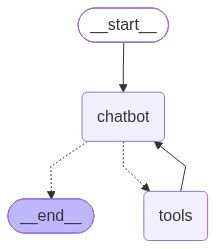

In [27]:
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode as PrebuiltToolNode
from langgraph.prebuilt import tools_condition as prebuilt_tools_condition

prebuilt_tool_node = PrebuiltToolNode(tools)

prebuilt_workflow = StateGraph(State)
prebuilt_workflow.add_node("chatbot", chatbot)
prebuilt_workflow.add_node("tools", prebuilt_tool_node) # Tool Node 등록

prebuilt_workflow.add_edge(START, 'chatbot')
prebuilt_workflow.add_edge('tools', 'chatbot')

prebuilt_workflow.add_conditional_edges(
    "chatbot",
    prebuilt_tools_condition, # Tool 요청 유무로 다음 노드 판별하는 함수
)

prebuilt_graph = prebuilt_workflow.compile()
prebuilt_graph

In [29]:
user_input = "LangGraph PreBuilt에 대해서 검색 Tool 사용해서 알려줘"
initial_state = {
    "messages": [HumanMessage(content=user_input)],
}

final_state = prebuilt_graph.invoke(initial_state)

trace_summary = summarize_messages(final_state["messages"])
display(trace_summary)

Markdown(final_state["messages"][-1].text)

[{'message_type': 'human', 'tool_calls': [], 'tool_call_id': None},
 {'message_type': 'ai',
  'tool_calls': [{'name': 'tavily_search',
    'id': 'call_KfJkQFIZoMVBN4RKDuWvXBM2'}],
  'tool_call_id': None},
 {'message_type': 'tool',
  'tool_calls': [],
  'tool_call_id': 'call_KfJkQFIZoMVBN4RKDuWvXBM2'},
 {'message_type': 'ai',
  'tool_calls': [{'name': 'tavily_search',
    'id': 'call_qHxXkM5wVa810Vg6pn7jr7LH'}],
  'tool_call_id': None},
 {'message_type': 'tool',
  'tool_calls': [],
  'tool_call_id': 'call_qHxXkM5wVa810Vg6pn7jr7LH'},
 {'message_type': 'ai', 'tool_calls': [], 'tool_call_id': None}]

## LangGraph PreBuilt란?

LangGraph의 **PreBuilt**는 에이전트 그래프를 처음부터 직접 구성하지 않고도 사용할 수 있도록 제공되는 **사전 구현 컴포넌트**입니다.

일반적으로 다음과 같은 작업을 대신 처리합니다.

- LLM 호출
- Tool 호출 및 결과 반환
- Tool 호출 여부에 따른 분기
- 메시지 상태 관리
- 여러 Tool의 병렬 실행
- Tool 실행 오류 처리
- ReAct 방식의 에이전트 루프 구성

즉, LangGraph의 저수준 그래프 API인 `StateGraph`를 직접 작성하지 않고도 기본적인 Tool 기반 에이전트를 빠르게 만들 수 있습니다.

> 참고: 현재 LangChain 생태계에서는 `langgraph.prebuilt.create_react_agent`보다 `langchain.agents.create_agent` 사용을 권장하는 방향으로 API가 이동하고 있습니다. 프로젝트의 LangGraph/LangChain 버전에 따라 API가 다를 수 있습니다.

---

## 대표적인 PreBuilt 구성 요소

### 1. `create_react_agent`

가장 대표적인 PreBuilt 에이전트 생성 함수입니다.

```python
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI

model = ChatOpenAI(model="gpt-4o-mini")

def search_web(query: str) -> str:
    """웹에서 검색합니다."""
    return f"{query}에 대한 검색 결과입니다."

agent = create_react_agent(
    model=model,
    tools=[search_web],
)

result = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": "LangGraph PreBuilt가 무엇인지 검색해줘"
        }
    ]
})

print(result["messages"][-1].content)
```

내부적으로는 대략 다음과 같은 흐름을 갖습니다.

```text
사용자 메시지
    ↓
LLM 호출
    ↓
Tool 호출이 필요한가?
    ├─ 아니오 → 최종 답변
    └─ 예
        ↓
      Tool 실행
        ↓
      Tool 결과를 LLM에 전달
        ↓
      다시 LLM 호출
```

이러한 구조를 일반적으로 **ReAct Agent**라고 부릅니다.

---

### 2. `ToolNode`

Tool 실행만 담당하는 노드입니다.

```python
from langgraph.prebuilt import ToolNode

tool_node = ToolNode([search_web])
```

`ToolNode`는 다음 기능을 제공합니다.

- 모델이 요청한 Tool 실행
- 여러 Tool call 실행
- Tool 결과를 `ToolMessage`로 변환
- Tool 실행 오류 처리
- Tool 호출에 필요한 상태 주입

직접 그래프를 설계하고 싶을 때 주로 사용합니다.

---

### 3. `tools_condition`

현재 메시지에 Tool 호출이 있는지 확인하고 그래프를 분기하는 조건 함수입니다.

```python
from langgraph.prebuilt import tools_condition
```

예를 들어 다음과 같은 그래프를 구성할 수 있습니다.

```text
LLM 노드
  ├─ Tool call 있음 → ToolNode
  └─ Tool call 없음 → 종료
```

---

## 직접 그래프를 구성하는 예시

`create_react_agent`를 사용하지 않고 `StateGraph`와 PreBuilt 컴포넌트를 조합할 수도 있습니다.

```python
from typing import Annotated
from typing_extensions import TypedDict

from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition


class State(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]


def search_web(query: str) -> str:
    """웹에서 검색합니다."""
    return f"{query}에 대한 검색 결과입니다."


model = ChatOpenAI(model="gpt-4o-mini")
tools = [search_web]

model_with_tools = model.bind_tools(tools)


def call_model(state: State):
    response = model_with_tools.invoke(state["messages"])
    return {"messages": [response]}


builder = StateGraph(State)

builder.add_node("agent", call_model)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "agent")

builder.add_conditional_edges(
    "agent",
    tools_condition,
    {
        "tools": "tools",
        END: END,
    },
)

builder.add_edge("tools", "agent")

graph = builder.compile()

result = graph.invoke({
    "messages": [
        {
            "role": "user",
            "content": "LangGraph를 설명해줘"
        }
    ]
})

print(result["messages"][-1].content)
```

이 방식의 장점은 다음과 같습니다.

- 특정 단계에 검증 로직 추가
- Tool 실행 전후에 별도 노드 삽입
- 승인 절차 추가
- 여러 Agent 연결
- 조건별 라우팅
- Human-in-the-loop 구현
- 사용자 정의 State 사용

---

## PreBuilt를 사용하면 좋은 경우

다음과 같은 경우에는 PreBuilt가 적합합니다.

### 빠른 프로토타이핑

Tool 몇 개를 연결해서 에이전트를 빠르게 테스트할 수 있습니다.

```python
agent = create_react_agent(
    model=model,
    tools=[calculator, search, database_query],
)
```

### 단순한 ReAct Agent

다음과 같은 구조라면 PreBuilt로 충분합니다.

```text
질문 → LLM 판단 → Tool 호출 → 결과 분석 → 답변
```

### LangGraph를 처음 사용하는 경우

StateGraph의 노드, 엣지, 조건부 분기를 모두 직접 작성하지 않아도 되기 때문에 학습 진입 장벽이 낮습니다.

---

## 직접 그래프를 작성해야 하는 경우

다음 상황에서는 PreBuilt만으로는 부족할 수 있습니다.

- Tool 실행 전에 사용자 승인이 필요함
- 특정 Tool은 반드시 관리자만 실행해야 함
- Tool 실행 결과에 따라 여러 경로로 분기해야 함
- 여러 Agent가 협업해야 함
- 장기 실행 작업을 중단 후 재개해야 함
- 복잡한 상태 관리가 필요함
- 각 단계의 입력과 출력을 엄격하게 검증해야 함
- 에이전트 실행 중 사람이 개입해야 함

이 경우에는 `StateGraph`, `Command`, `interrupt`, `checkpointer` 등을 직접 사용하는 방식이 적합합니다.

---

## `create_react_agent`와 최신 `create_agent`의 관계

과거에는 보통 다음과 같이 작성했습니다.

```python
from langgraph.prebuilt import create_react_agent
```

현재 LangChain 문서의 새로운 Agent API에서는 다음 형태가 권장됩니다.

```python
from langchain.agents import create_agent

agent = create_agent(
    model="openai:gpt-4o-mini",
    tools=[search_web],
)
```

따라서 새 프로젝트라면 다음을 확인하는 것이 좋습니다.

```bash
pip show langgraph
pip show langchain
```

그리고 설치된 버전의 공식 문서에 맞춰 API를 사용해야 합니다. 특히 다음 요소들은 버전에 따라 달라질 수 있습니다.

- `create_react_agent`의 위치
- `create_agent` 지원 여부
- `version="v1"` 또는 `version="v2"`
- State schema 지정 방식
- Tool 결과 형식
- `response_format` 설정 방식

---

## PreBuilt의 장점과 단점

| 구분 | 내용 |
|---|---|
| 장점 | 코드가 짧음 |
| 장점 | Tool 기반 Agent를 빠르게 구현 가능 |
| 장점 | Tool 실행, 메시지 관리, 반복 루프가 기본 제공됨 |
| 장점 | LangGraph의 체크포인트와 결합 가능 |
| 단점 | 내부 흐름을 세밀하게 제어하기 어려움 |
| 단점 | 복잡한 분기와 승인 절차에는 한계가 있음 |
| 단점 | LangChain/LangGraph 버전에 따른 API 변화가 있음 |
| 단점 | 단순한 Agent라도 내부적으로 여러 번 LLM을 호출할 수 있음 |

---

## 핵심 정리

LangGraph PreBuilt는 다음과 같이 이해하면 됩니다.

> **LangGraph의 일반적인 Agent 패턴을 미리 그래프로 구현해 둔 도구 모음**

가장 많이 사용하는 구성은 다음과 같습니다.

```python
from langgraph.prebuilt import create_react_agent
```

세부 동작을 직접 제어하려면 다음을 조합합니다.

```python
from langgraph.prebuilt import ToolNode, tools_condition
```

추천 사용 기준은 다음과 같습니다.

- 단순 Tool Agent: `create_react_agent` 또는 최신 `create_agent`
- Tool 실행 노드만 재사용: `ToolNode`
- Tool 호출 여부에 따른 분기: `tools_condition`
- 복잡한 업무 흐름: `StateGraph` 직접 구성

공식 참고 링크:

- LangGraph 공식 문서: https://langchain-ai.github.io/langgraph/
- LangGraph Prebuilt API: https://langchain-ai.github.io/langgraph/reference/agents/
- LangChain Agents 문서: https://docs.langchain.com/oss/python/langchain/agents

검색 Tool을 사용해 공식 문서를 조회하려고 했지만, 현재 검색 서비스 인증 오류로 실시간 결과를 가져오지는 못했습니다. 따라서 위 내용은 LangGraph 공식 API 구조와 일반적인 사용법을 기준으로 정리한 것입니다.